# E-commerce Sales & Customer Analytics
**Author:** G Kranthi Kumar  |  **Program:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 | BharatCares

**Dataset:** [E-Commerce Sales and Customer Analytics (Kaggle)](https://www.kaggle.com/datasets/datascikhan/e-commerce-sales-and-customer-analytics)

### Objective
1. Clean and validate the sales data.
2. Explore sales, profit, channels, regions, products and delivery performance.
3. Segment customers with **RFM features + K-Means clustering** and turn each segment into a business action.

### Files used
| File | Content |
|---|---|
| `ecommerce_sales_customer_analytics_150k.csv` | One row per order (138,116 orders, 46 columns) |
| `order_items.csv` | One row per product line in an order (397,569 rows) |
| `product_catalog.csv` | Product category, brand, price, cost (1,175 products) |
| `customer_master.csv` | Customer profile and acquisition cost (25,000 customers) |
| `dataset_statistics.csv` | Dataset-level summary figures from the publisher |

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12})
PALETTE = ["#2E5E8C", "#E08A2E", "#3C8D6B", "#B5473A", "#7A5C99", "#8A8A8A"]
RANDOM_STATE = 42

def money(x, _=None):
    # compact axis label: 1.2M, 340K
    return f"{x/1e6:.1f}M" if abs(x) >= 1e6 else f"{x/1e3:.0f}K"

## 1. Load the data
Put the CSV files in the same folder as this notebook (or in a `data/` sub-folder).

In [2]:
def find_file(name):
    for folder in [".", "data", "/content", "/content/data",
                   "/kaggle/input/e-commerce-sales-and-customer-analytics"]:
        path = os.path.join(folder, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"{name} not found. Download the dataset from Kaggle and place it next to this notebook.")

sales     = pd.read_csv(find_file("ecommerce_sales_customer_analytics_150k.csv"))
items     = pd.read_csv(find_file("order_items.csv"))
products  = pd.read_csv(find_file("product_catalog.csv"))
customers = pd.read_csv(find_file("customer_master.csv"))
stats     = pd.read_csv(find_file("dataset_statistics.csv"))

for name, d in [("sales", sales), ("order_items", items), ("product_catalog", products), ("customer_master", customers)]:
    print(f"{name:<16} {d.shape[0]:>8,} rows x {d.shape[1]:>2} columns")

sales             138,116 rows x 46 columns
order_items       397,569 rows x 12 columns
product_catalog     1,175 rows x  9 columns
customer_master    25,000 rows x 11 columns


## 2. Data quality check

In [3]:
missing = sales.isna().sum()
missing = missing[missing > 0].to_frame("missing_rows")
missing["missing_%"] = (missing["missing_rows"] / len(sales) * 100).round(1)
print("Duplicate rows in sales   :", sales.duplicated().sum())
print("Duplicate order_id        :", sales["order_id"].duplicated().sum())
print("Missing values in items / products / customers:",
      items.isna().sum().sum(), "/", products.isna().sum().sum(), "/", customers.isna().sum().sum())
print("\nColumns with missing values in the sales file:")
missing

Duplicate rows in sales   : 0
Duplicate order_id        : 0
Missing values in items / products / customers: 0 / 0 / 0

Columns with missing values in the sales file:


,missing_rows,missing_%
delivery_days,24557,17.8
estimated_delivery_days,24557,17.8
return_status,128654,93.1
return_reason,128654,93.1
customer_rating,24557,17.8
review_sentiment,24557,17.8
customer_review,24557,17.8
campaign_name,83233,60.3
coupon_code,110502,80.0


In [4]:
# Are the missing values genuine problems or expected?
cancelled = sales["order_status"].eq("Cancelled")
print("Rows with no delivery_days            :", sales["delivery_days"].isna().sum())
print("Cancelled orders                      :", cancelled.sum())
not_completed = sales["order_status"].ne("Completed")
print("Orders that are not Completed (cancelled, returned, pending):", not_completed.sum())
print("Missing delivery_days that are not Completed:", (sales["delivery_days"].isna() & not_completed).sum())
print("Missing return_reason that are not returned:",
      (sales["return_reason"].isna() & sales["return_status"].isna()).sum(), "of", sales["return_reason"].isna().sum())
print("\nNegative-profit orders:", (sales["profit"] < 0).sum(), f"({(sales['profit'] < 0).mean():.1%})")
print("Orders with quantity <= 0 or net_sales <= 0:", ((sales['quantity'] <= 0) | (sales['net_sales'] <= 0)).sum())

Rows with no delivery_days            : 24557
Cancelled orders                      : 8398
Orders that are not Completed (cancelled, returned, pending): 24557
Missing delivery_days that are not Completed: 24557
Missing return_reason that are not returned: 128654 of 128654

Negative-profit orders: 1296 (0.9%)
Orders with quantity <= 0 or net_sales <= 0: 0


**Findings**
- No duplicate orders, and no missing values in the order items, product catalog or customer master.
- Missing values in the sales file are **structural, not errors**: delivery and review fields are empty exactly for the orders that are not Completed (cancelled, returned or pending), `return_reason` is empty for orders that were not returned, and coupon/campaign fields are empty when no coupon or campaign was used. They are kept, not imputed.
- Only 0.9% of orders (1,296) have negative profit, almost all with discounts of 50% or more. These are real business outcomes, so they are kept and analysed in section 5.

## 3. Cleaning and feature preparation

In [5]:
df = sales.copy()
df["order_date"] = pd.to_datetime(df["order_date"])
df["year"]  = df["order_date"].dt.year
df["month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()
df["hour"]  = pd.to_datetime(df["order_time"], format="%H:%M:%S").dt.hour
df["weekday"] = df["order_date"].dt.day_name()
df["discount_rate"] = df["discount_amount"] / df["gross_sales"]
df["is_returned"]  = df["order_status"].eq("Returned")
df["is_cancelled"] = df["order_status"].eq("Cancelled")
df["is_delayed"]   = df["delivery_status"].eq("Delayed")

# "Valid" orders = revenue-generating orders (not cancelled, not returned, not pending)
valid = df[df["order_status"] == "Completed"].copy()
print(f"All orders: {len(df):,}   |   Completed (used for revenue analysis): {len(valid):,} ({len(valid)/len(df):.1%})")
print("Date range:", df["order_date"].min().date(), "to", df["order_date"].max().date())
df["order_status"].value_counts().to_frame("orders").assign(share=lambda t: (t["orders"]/t["orders"].sum()).map("{:.1%}".format))

All orders: 138,116   |   Completed (used for revenue analysis): 113,559 (82.2%)
Date range: 2021-01-01 to 2025-12-31


,orders,share
order_status,,
Completed,113559,82.2%
Returned,9462,6.9%
Cancelled,8398,6.1%
Pending,6697,4.8%


## 4. Business KPIs

In [6]:
kpi = pd.Series({
    "Total orders": len(df),
    "Unique customers": df["customer_id"].nunique(),
    "Total net sales (all orders)": df["net_sales"].sum(),
    "Total profit (all orders)": df["profit"].sum(),
    "Average order value": df["net_sales"].mean(),
    "Profit margin on net sales": df["profit"].sum() / df["net_sales"].sum(),
    "Return rate": df["is_returned"].mean(),
    "Cancellation rate": df["is_cancelled"].mean(),
    "Average customer rating": df["customer_rating"].mean(),
    "Delayed deliveries (share of delivered)": df.loc[df["delivery_days"].notna(), "is_delayed"].mean(),
})
fmt = {"Total orders": "{:,.0f}", "Unique customers": "{:,.0f}", "Total net sales (all orders)": "{:,.2f}",
       "Total profit (all orders)": "{:,.2f}", "Average order value": "{:,.2f}", "Profit margin on net sales": "{:.1%}",
       "Return rate": "{:.2%}", "Cancellation rate": "{:.2%}", "Average customer rating": "{:.2f}",
       "Delayed deliveries (share of delivered)": "{:.1%}"}
kpi_table = pd.DataFrame({"Value": [fmt[k].format(v) for k, v in kpi.items()]}, index=kpi.index)
display(kpi_table)
print("Publisher's dataset_statistics.csv for comparison:")
display(stats.T.rename(columns={0: "Published value"}))

Publisher's dataset_statistics.csv for comparison:


,Value
Total orders,"138,116"
Unique customers,"24,911"
Total net sales (all orders),"177,134,263.74"
Total profit (all orders),"76,146,395.76"
Average order value,"1,282.50"
Profit margin on net sales,43.0%
Return rate,6.85%
Cancellation rate,6.08%
Average customer rating,3.68
Delayed deliveries (share of delivered),14.9%


,Published value
Total Transactions,138116
Total Columns,46
Total Customers,24911
Total Products Used,138116
Date Range,2021-01-01 to 2025-12-31
Total Revenue,"$177,134,263.74"
Total Profit,"$76,146,395.76"
Average Order Value,"$1,282.50"
Average Rating,3.68
Return Rate,6.85%


The computed KPIs match the publisher's statistics (revenue, profit, order value, return and cancellation rates).

> **Note on currency:** the `currency` column holds seven currencies (USD, GBP, EUR, CAD, AUD, INR, AED), but the amounts are not converted. Totals are therefore reported as the dataset's own units, as the publisher does, and not as a true single-currency figure.

## 5. Exploratory data analysis

Strongest month of the year: December | weakest: February


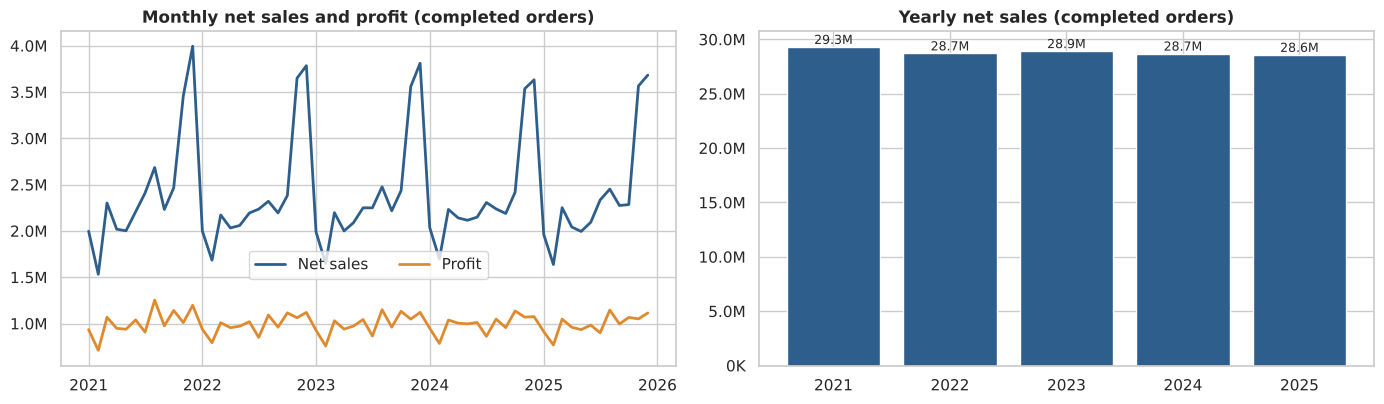

In [7]:
# 5.1 Sales and profit trend (completed orders)
monthly = valid.groupby("month").agg(net_sales=("net_sales", "sum"), profit=("profit", "sum"), orders=("order_id", "count"))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(monthly.index, monthly["net_sales"], color=PALETTE[0], lw=2, label="Net sales")
axes[0].plot(monthly.index, monthly["profit"], color=PALETTE[1], lw=2, label="Profit")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(money))
axes[0].set_title("Monthly net sales and profit (completed orders)")
axes[0].legend(loc="center", bbox_to_anchor=(0.5, 0.3), ncol=2)

yearly = valid.groupby("year")["net_sales"].sum()
axes[1].bar(yearly.index.astype(str), yearly.values, color=PALETTE[0])
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(money))
axes[1].set_title("Yearly net sales (completed orders)")
for i, v in enumerate(yearly.values):
    axes[1].text(i, v, money(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

m = valid.groupby(valid["order_date"].dt.month)["net_sales"].sum()
print("Strongest month of the year:", pd.Timestamp(2000, int(m.idxmax()), 1).strftime("%B"),
      "| weakest:", pd.Timestamp(2000, int(m.idxmin()), 1).strftime("%B"))

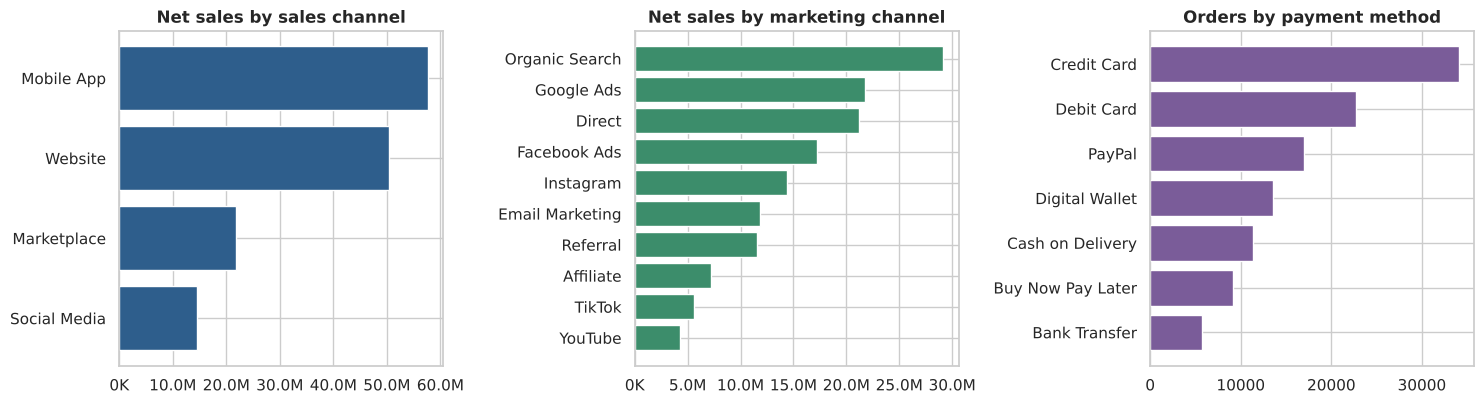

,orders,net_sales,aov,margin
sales_channel,,,,
Mobile App,45505,57617393.0,1266.0,41.4%
Website,39606,50345188.0,1271.0,41.5%
Marketplace,16987,21775780.0,1282.0,41.3%
Social Media,11461,14457478.0,1261.0,41.6%


In [8]:
# 5.2 Channels, marketing and payment
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ch = valid.groupby("sales_channel")["net_sales"].sum().sort_values()
axes[0].barh(ch.index, ch.values, color=PALETTE[0]); axes[0].set_title("Net sales by sales channel")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(money))

mk = valid.groupby("marketing_channel")["net_sales"].sum().sort_values()
axes[1].barh(mk.index, mk.values, color=PALETTE[2]); axes[1].set_title("Net sales by marketing channel")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(money))

pm = valid["payment_method"].value_counts().sort_values()
axes[2].barh(pm.index, pm.values, color=PALETTE[4]); axes[2].set_title("Orders by payment method")
plt.tight_layout(); plt.show()

channel_perf = valid.groupby("sales_channel").agg(orders=("order_id", "count"), net_sales=("net_sales", "sum"),
        aov=("net_sales", "mean"), margin=("profit", lambda p: p.sum() / valid.loc[p.index, "net_sales"].sum()))
channel_perf["margin"] = channel_perf["margin"].map("{:.1%}".format)
channel_perf.round(0).sort_values("net_sales", ascending=False)

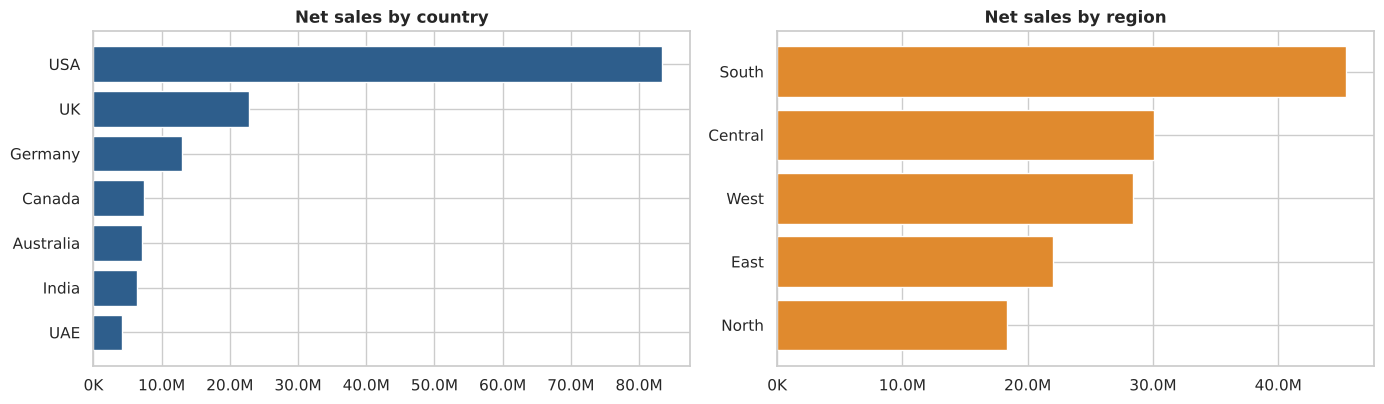

In [9]:
# 5.3 Geography
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
co = valid.groupby("customer_country")["net_sales"].sum().sort_values()
axes[0].barh(co.index, co.values, color=PALETTE[0]); axes[0].set_title("Net sales by country")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(money))
rg = valid.groupby("region")["net_sales"].sum().sort_values()
axes[1].barh(rg.index, rg.values, color=PALETTE[1]); axes[1].set_title("Net sales by region")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(money))
plt.tight_layout(); plt.show()

Order lines with no matching product: 0
Top 10 brands by net sales:


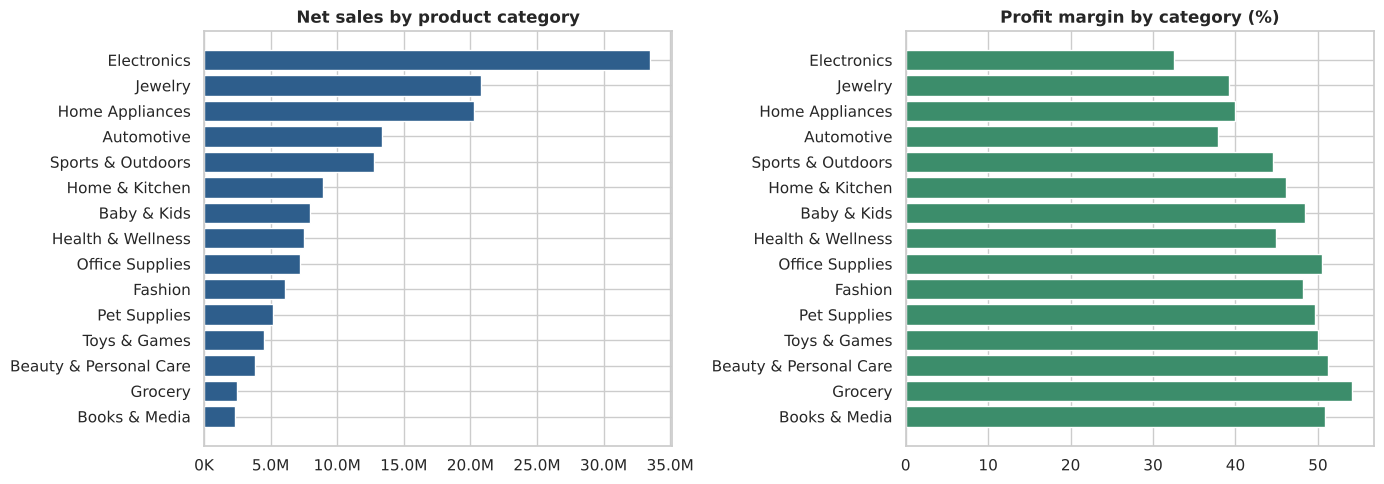

,net_sales
brand,
Samsung,5674878.0
LG,5045965.0
OnePlus,4123879.0
Asus,3921121.0
HP,3702926.0
David Yurman,3651658.0
Whirlpool,3335381.0
Pandora,3044302.0
Sony,3011616.0


In [10]:
# 5.4 Products: join order lines to the product catalogue
lines = items.merge(products[["product_id", "product_category", "product_subcategory", "brand", "product_rating"]],
                    on="product_id", how="left")
lines = lines[lines["order_id"].isin(valid["order_id"])]
print("Order lines with no matching product:", lines["product_category"].isna().sum())

cat = lines.groupby("product_category").agg(net_sales=("net_sales", "sum"), profit=("profit", "sum"), units=("quantity", "sum"))
cat["margin"] = cat["profit"] / cat["net_sales"]
cat = cat.sort_values("net_sales")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cat.index, cat["net_sales"], color=PALETTE[0]); axes[0].set_title("Net sales by product category")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(money))
axes[1].barh(cat.index, cat["margin"] * 100, color=PALETTE[2]); axes[1].set_title("Profit margin by category (%)")
plt.tight_layout(); plt.show()

top_brands = lines.groupby("brand")["net_sales"].sum().nlargest(10)
print("Top 10 brands by net sales:")
top_brands.round(0).to_frame("net_sales")

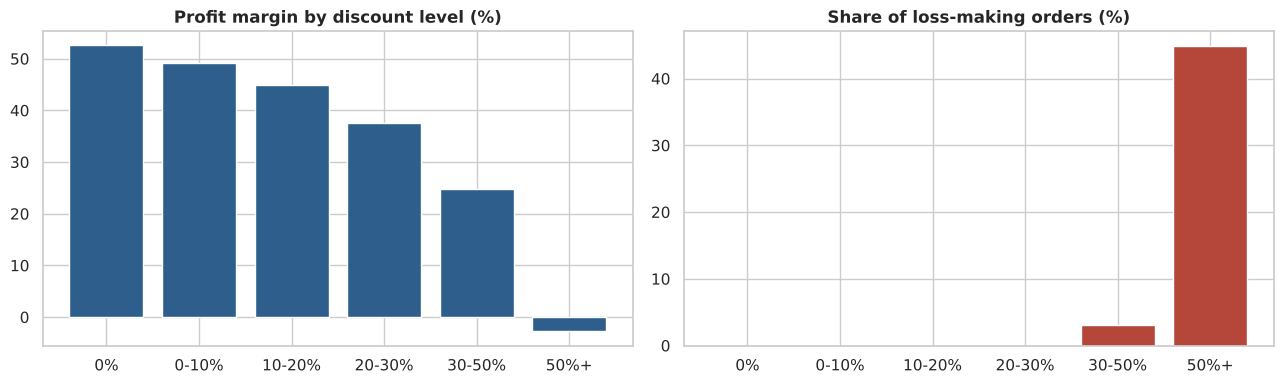

,orders,margin,loss_making
discount_band,,,
0%,17864,52.6%,0.0%
0-10%,35031,49.2%,0.0%
10-20%,49198,44.9%,0.0%
20-30%,17729,37.6%,0.0%
30-50%,16565,24.8%,3.1%
50%+,1729,-2.7%,44.9%


In [11]:
# 5.5 Discounts versus profitability
df["discount_band"] = pd.cut(df["discount_rate"], [-0.001, 0.0, 0.1, 0.2, 0.3, 0.5, 1.0],
                             labels=["0%", "0-10%", "10-20%", "20-30%", "30-50%", "50%+"])
band = df.groupby("discount_band", observed=True).agg(orders=("order_id", "count"),
        margin=("profit", lambda p: p.sum() / df.loc[p.index, "net_sales"].sum()),
        loss_making=("profit", lambda p: (p < 0).mean()))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(band.index.astype(str), band["margin"] * 100, color=PALETTE[0]); axes[0].set_title("Profit margin by discount level (%)")
axes[1].bar(band.index.astype(str), band["loss_making"] * 100, color=PALETTE[3]); axes[1].set_title("Share of loss-making orders (%)")
plt.tight_layout(); plt.show()
band.assign(margin=band["margin"].map("{:.1%}".format), loss_making=band["loss_making"].map("{:.1%}".format))

Return reasons (top 5):


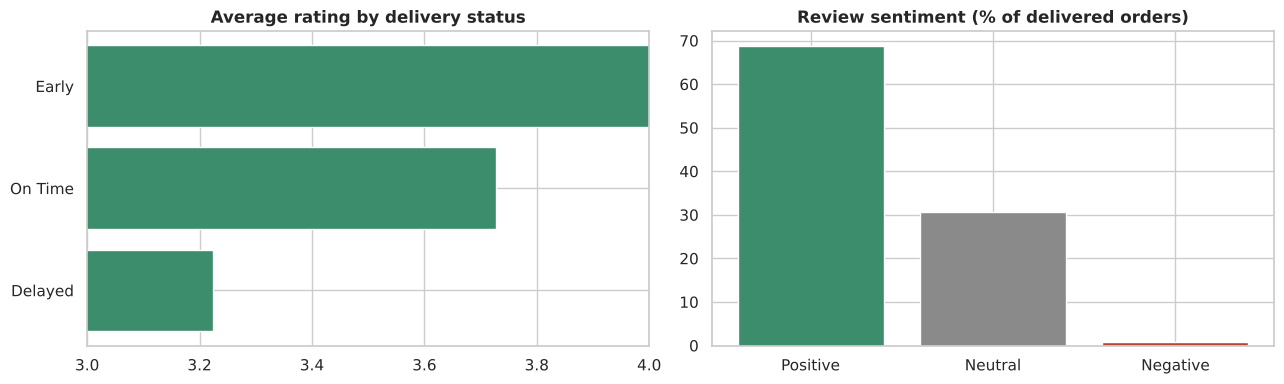

,returns
return_reason,
Wrong Product,1237
Other,1208
Changed Mind,1204
Size Issue,1182
Defective Product,1174


In [12]:
# 5.6 Delivery performance and customer satisfaction
delivered = df[df["delivery_days"].notna()]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rating_by_status = delivered.groupby("delivery_status")["customer_rating"].mean().sort_values()
axes[0].barh(rating_by_status.index, rating_by_status.values, color=PALETTE[2])
axes[0].set_xlim(3, 4); axes[0].set_title("Average rating by delivery status")
sent = delivered["review_sentiment"].value_counts(normalize=True) * 100
axes[1].bar(sent.index, sent.values, color=[PALETTE[2], PALETTE[5], PALETTE[3]][:len(sent)])
axes[1].set_title("Review sentiment (% of delivered orders)")
plt.tight_layout(); plt.show()

print("Return reasons (top 5):")
df["return_reason"].value_counts().head(5).to_frame("returns")

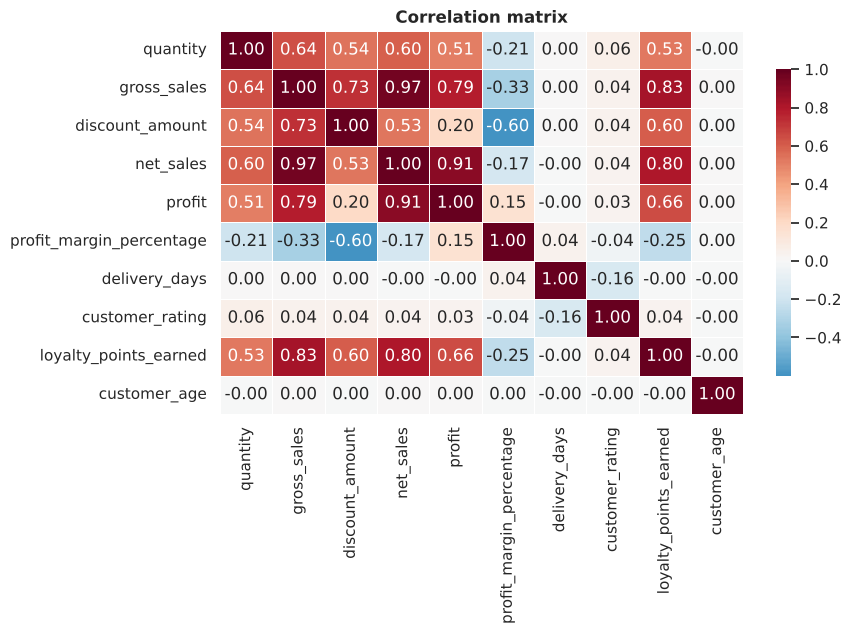

In [13]:
# 5.7 Correlation between key numeric variables
cols = ["quantity", "gross_sales", "discount_amount", "net_sales", "profit", "profit_margin_percentage",
        "delivery_days", "customer_rating", "loyalty_points_earned", "customer_age"]
plt.figure(figsize=(9, 6.5))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Correlation matrix"); plt.tight_layout(); plt.show()

## 6. Customer segmentation with RFM and K-Means

**RFM** summarises each customer with three behaviours:
- **Recency**: days since the last completed order (lower is better)
- **Frequency**: number of completed orders
- **Monetary**: total net sales from completed orders

I add the **average discount rate** to show how price-sensitive each customer is. IDs, postal codes and other columns without behavioural meaning are not used. This replaces clustering on every numeric column, which mixes identifiers with real behaviour.

In [14]:
snapshot = valid["order_date"].max() + pd.Timedelta(days=1)
rfm = valid.groupby("customer_id").agg(
    Recency=("order_date", lambda d: (snapshot - d.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("net_sales", "sum"),
    AvgDiscountRate=("discount_rate", "mean"),
)
print(f"Customers with at least one completed order: {len(rfm):,} of {df['customer_id'].nunique():,}")
rfm.describe().round(2)

Customers with at least one completed order: 24,748 of 24,911


,Recency,Frequency,Monetary,AvgDiscountRate
count,24748.00,24748.00,24748.00,24748.00
mean,364.40,4.59,5826.57,0.17
std,349.99,2.08,3629.48,0.07
min,1.00,1.00,22.55,0.00
25%,89.00,3.00,3098.38,0.13
50%,261.00,4.00,5225.85,0.17
75%,526.25,6.00,7904.70,0.21
max,1826.00,15.00,27671.95,0.60


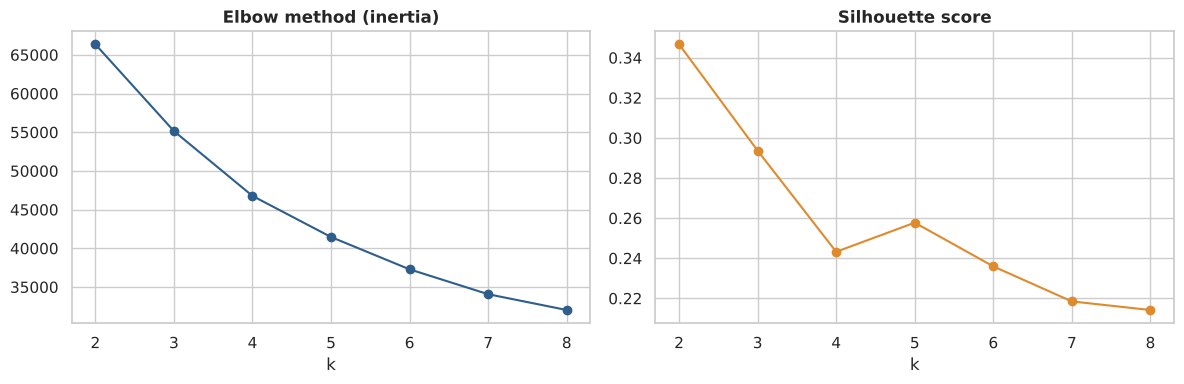

,inertia,silhouette
k,,
2,66359.0,0.347
3,55146.0,0.294
4,46769.0,0.243
5,41459.0,0.258
6,37282.0,0.236
7,34071.0,0.218
8,32028.0,0.214


In [15]:
# Monetary and Frequency are right-skewed -> log transform before scaling
features = ["Recency", "Frequency", "Monetary", "AvgDiscountRate"]
X = rfm[features].copy()
X["Frequency"] = np.log1p(X["Frequency"])
X["Monetary"]  = np.log1p(X["Monetary"])
X_scaled = StandardScaler().fit_transform(X)

# Elbow method + silhouette score to choose k
ks = range(2, 9)
inertia, sil = [], []
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled[sample_idx], km.labels_[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertia, "o-", color=PALETTE[0]); axes[0].set_title("Elbow method (inertia)"); axes[0].set_xlabel("k")
axes[1].plot(list(ks), sil, "o-", color=PALETTE[1]); axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()
pd.DataFrame({"k": list(ks), "inertia": np.round(inertia), "silhouette": np.round(sil, 3)}).set_index("k")

In [16]:
# Silhouette is highest at k=2 (a simple active/inactive split) and the elbow flattens gradually after k=4.
# k=4 is chosen as the smallest k that gives clearly different, actionable business segments.
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
rfm["Cluster"] = kmeans.labels_

profile = rfm.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    AvgDiscountRate=("AvgDiscountRate", "mean"),
)
profile["Share_of_revenue"] = rfm.groupby("Cluster")["Monetary"].sum() / rfm["Monetary"].sum()
profile.round(2)

,Customers,Recency,Frequency,Monetary,AvgDiscountRate,Share_of_revenue
Cluster,,,,,,
0,9956,190.78,6.48,8817.46,0.17,0.61
1,7909,377.40,3.75,4358.75,0.14,0.24
2,2937,956.83,1.95,1904.01,0.15,0.04
3,3946,335.41,3.46,4141.87,0.27,0.11


In [17]:
# Name each cluster from its behaviour (rule-based, so names stay correct if clusters are renumbered)
def name_clusters(p):
    names = {}
    remaining = list(p.index)
    best = p.loc[remaining, "Monetary"].idxmax(); names[best] = "Champions"; remaining.remove(best)
    lost = p.loc[remaining, "Recency"].idxmax();  names[lost] = "At-Risk / Lapsed"; remaining.remove(lost)
    disc = p.loc[remaining, "AvgDiscountRate"].idxmax(); names[disc] = "Discount Seekers"; remaining.remove(disc)
    for c in remaining:
        names[c] = "Steady Regulars"
    return names

cluster_names = name_clusters(profile)
rfm["Segment"] = rfm["Cluster"].map(cluster_names)
profile["Segment"] = profile.index.map(cluster_names)
seg = profile.set_index("Segment").sort_values("Monetary", ascending=False)
seg_display = seg.drop(columns="Cluster", errors="ignore").copy()
seg_display["Share_of_revenue"] = seg_display["Share_of_revenue"].map("{:.1%}".format)
seg_display["AvgDiscountRate"] = seg_display["AvgDiscountRate"].map("{:.1%}".format)
seg_display.round(1)

,Customers,Recency,Frequency,Monetary,AvgDiscountRate,Share_of_revenue
Segment,,,,,,
Champions,9956,190.8,6.5,8817.5,17.3%,60.9%
Steady Regulars,7909,377.4,3.7,4358.7,13.6%,23.9%
Discount Seekers,3946,335.4,3.5,4141.9,27.3%,11.3%
At-Risk / Lapsed,2937,956.8,1.9,1904.0,14.5%,3.9%


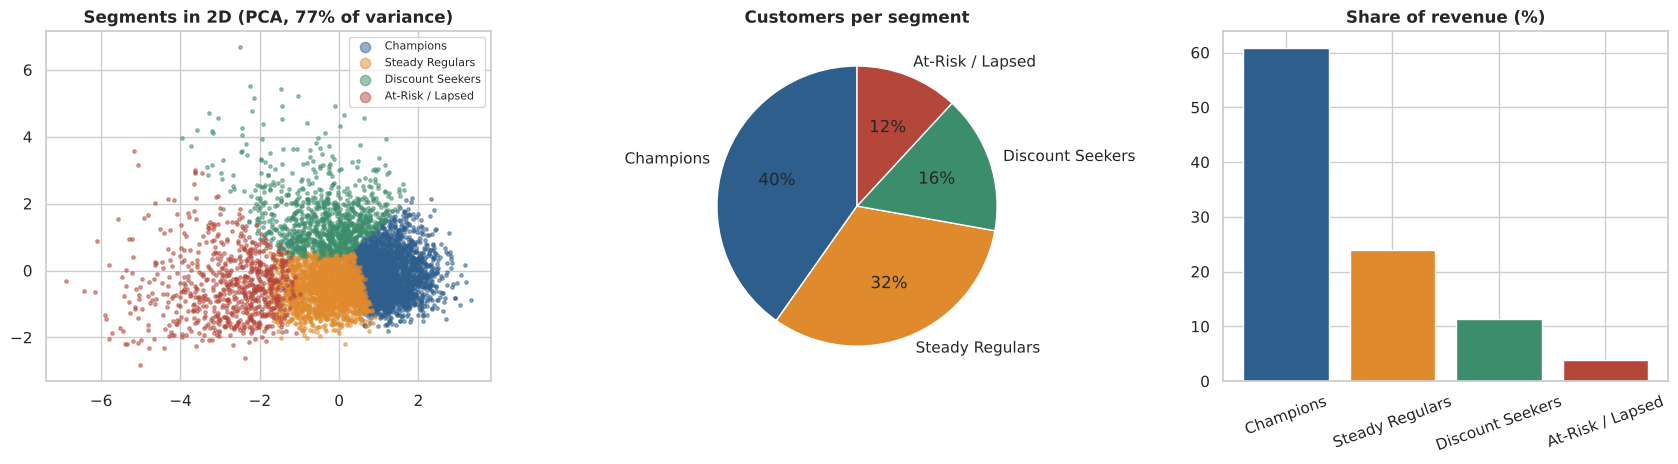

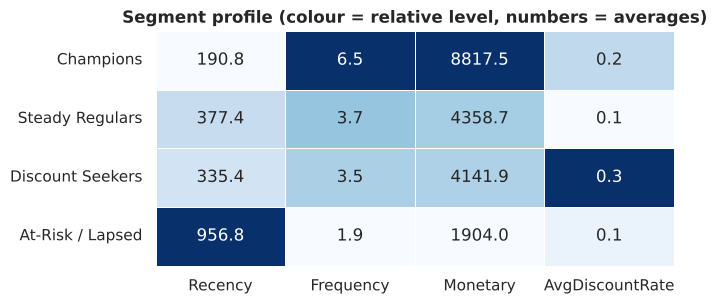

In [18]:
# Visualise the segments
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
order = list(seg.index)
colors = dict(zip(order, PALETTE))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for s in order:
    mask = (rfm["Segment"] == s).values
    axes[0].scatter(coords[mask, 0][::4], coords[mask, 1][::4], s=6, alpha=.5, color=colors[s], label=s)
axes[0].set_title(f"Segments in 2D (PCA, {pca.explained_variance_ratio_.sum():.0%} of variance)")
axes[0].legend(markerscale=3, fontsize=8)

axes[1].pie(seg["Customers"], labels=seg.index, autopct="%1.0f%%", colors=[colors[s] for s in seg.index], startangle=90)
axes[1].set_title("Customers per segment")

axes[2].bar(seg.index, seg["Share_of_revenue"] * 100, color=[colors[s] for s in seg.index])
axes[2].set_title("Share of revenue (%)"); axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

# Normalised profile heatmap
norm = (seg[features] - seg[features].min()) / (seg[features].max() - seg[features].min())
plt.figure(figsize=(7, 3.2))
sns.heatmap(norm, annot=seg[features].round(1), fmt="", cmap="Blues", cbar=False, linewidths=.5)
plt.title("Segment profile (colour = relative level, numbers = averages)"); plt.ylabel("")
plt.tight_layout(); plt.show()

In [19]:
# Link segments to the customer master (who are these customers?)
cust = customers.merge(rfm[["Segment", "Recency", "Frequency", "Monetary"]], left_on="customer_id", right_index=True, how="inner")
mix = pd.crosstab(cust["Segment"], cust["customer_segment"], normalize="index").mul(100).round(1)
print("Share of each RFM segment by the company's own customer tier (%):")
display(mix)
print("Average customer age and acquisition cost by segment:")
cust.groupby("Segment").agg(avg_age=("customer_age", "mean"), avg_acquisition_cost=("customer_acquisition_cost", "mean")).round(1)

Share of each RFM segment by the company's own customer tier (%):
Average customer age and acquisition cost by segment:


customer_segment,Business,Consumer,Premium,VIP
Segment,,,,
At-Risk / Lapsed,11.0,56.3,23.7,9.0
Champions,10.0,55.6,24.4,10.0
Discount Seekers,6.7,34.7,42.0,16.6
Steady Regulars,11.5,62.6,18.3,7.6


,avg_age,avg_acquisition_cost
Segment,,
At-Risk / Lapsed,46.0,42.3
Champions,45.8,42.2
Discount Seekers,46.2,42.3
Steady Regulars,45.8,42.1


In [20]:
# Export the segment of every customer
out = rfm.reset_index()[["customer_id", "Recency", "Frequency", "Monetary", "AvgDiscountRate", "Segment"]]
out.to_csv("customer_segments.csv", index=False)
print("Saved customer_segments.csv with", len(out), "customers")
out.head()

Saved customer_segments.csv with 24748 customers


,customer_id,Recency,Frequency,Monetary,AvgDiscountRate,Segment
0,CUST-000001,7,7,9370.54,0.103871,Champions
1,CUST-000002,315,7,12713.84,0.129046,Champions
2,CUST-000003,210,6,7664.59,0.100963,Champions
3,CUST-000004,55,4,7382.98,0.368599,Discount Seekers
4,CUST-000005,413,8,10063.97,0.217916,Champions


## 7. Conclusions and recommendations


### Key findings
1. **Sales are flat but strongly seasonal.** Completed-order net sales are about 28.6M to 29.3M every year from 2021 to 2025, with no growth. November and December together bring about a quarter of annual sales, and February is the weakest month.
2. **The business depends on one market.** The USA produces about 58% of net sales, followed by the UK (16%) and Germany (9%). India and the UAE are the smallest markets.
3. **Channels perform almost identically.** Mobile App, Website, Marketplace and Social Media all have an average order value near 1,270 and a margin near 41%. The Mobile App is largest by volume, and Organic Search is the largest marketing channel.
4. **Electronics sells the most but earns the least per sale.** Electronics has the highest net sales and the lowest margin (about 33%). Grocery and Books & Media have margins above 50% but small sales.
5. **Heavy discounts destroy profit.** Margin falls from about 53% with no discount to 25% at 30-50% discount, and turns negative (-2.7%) at 50% or more, where 45% of orders lose money.
6. **Late delivery hurts satisfaction.** Delayed orders average a 3.2 rating, against 3.7 on time and 4.0 early. About 15% of delivered orders are delayed.
7. **Returns have no single cause.** Return reasons are spread almost evenly (wrong product, changed mind, size, defect), so there is no one fix.

### Customer segments (RFM + K-Means, k = 4)
| Segment | Customers | Typical behaviour | Revenue share | Recommended action |
|---|---|---|---|---|
| **Champions** | 40% | Buy often (about 6.5 orders), most recent, highest spend | 61% | Loyalty rewards, early access, protect with premium service |
| **Steady Regulars** | 32% | Moderate frequency and spend, low discount use | 24% | Cross-sell and bundles to raise order value |
| **Discount Seekers** | 16% | Average discount about 27% (the highest) | 11% | Cap discounts, use minimum-spend offers, since deep discounts lose money |
| **At-Risk / Lapsed** | 12% | Last order about 2.6 years ago, few orders | 4% | Win-back email campaigns with a time-limited offer |

Discount Seekers are over-represented among the company's own Premium and VIP tiers (about 59%, against 26% to 34% in the other segments), so the existing tier system does not stop heavy discounting.

### Limitations
- Amounts are in several currencies but are not converted, so totals are in the dataset's own units.
- The silhouette score for k = 4 is 0.24: segments overlap and form a continuum rather than sharply separated groups. They are useful for targeting, not exact boundaries.
- The data looks simulated (very even distributions, no growth trend), so the findings describe this dataset and may not match a real business.
- Segments use completed orders only; customers whose orders were all cancelled, returned or pending are excluded (163 customers).

### Next steps
Predict which Champions are likely to lapse, test discount caps with an A/B experiment, and convert currencies to a single base currency for a true revenue figure.
